# Test word search in the documents

In [9]:
import pandas as pd

df = pd.read_csv('output/2025-10-31/site_data.csv')
# deduplicate by 'Agency','Facility_Name'
df_dedup = df.drop_duplicates(subset=['Agency', 'Facility_Name'])
print(df_dedup.shape)
# print the % of 'Shared_PDF'==Yes
shared_pdf_percent = (df_dedup['Shared_PDF'] == 'Yes').mean() * 100
print(f"Percentage of Shared_PDF == 'Yes': {shared_pdf_percent:.2f}%")
# print % of each 'region' 
region_percent = df_dedup['Region'].value_counts(normalize=True) * 100
print("Percentage of each region:")
print(region_percent.sort_index())
# print % of each 'Major/Minor'
major_minor_percent = df_dedup['Major/Minor'].value_counts(normalize=True) * 100
print("Percentage of each Major/Minor:")
print(major_minor_percent.sort_index())

(142, 7)
Percentage of Shared_PDF == 'Yes': 13.38%
Percentage of each region:
Region
1     13.380282
2     17.605634
3      7.746479
4      6.338028
5F     2.112676
5R     9.859155
5S    19.718310
7      6.338028
8      6.338028
9     10.563380
Name: proportion, dtype: float64
Percentage of each Major/Minor:
Major/Minor
Major           64.788732
Major, Minor     8.450704
Minor           26.760563
Name: proportion, dtype: float64


In [19]:
n_train_data = 15
print('For ' + str(n_train_data) + ' facilities as train examples we need :')
# int value closest
print((region_percent.sort_index() / 100 * n_train_data).round())
print((major_minor_percent.sort_index() / 100 * n_train_data).round())

For 15 facilities as train examples we need :
Region
1     2.0
2     3.0
3     1.0
4     1.0
5F    0.0
5R    1.0
5S    3.0
7     1.0
8     1.0
9     2.0
Name: proportion, dtype: float64
Major/Minor
Major           10.0
Major, Minor     1.0
Minor            4.0
Name: proportion, dtype: float64


In [ ]:
# Find n_train_data rows such that the ratio of regions and major/minor in the sample matches the overall distribution as closely as possible.

from sklearn.model_selection import train_test_split

# Method 1: Stratified sampling by combining Region and Major/Minor
# Create a combined stratification column
df_dedup['strata'] = df_dedup['Region'].astype(str) + '_' + df_dedup['Major/Minor'].astype(str)

# Use stratified sampling to get n_train_data samples
try:
    train_sample = df_dedup.groupby('strata', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1, int(n_train_data * len(x) / len(df_dedup)))))
    )
    
    # If we don't have exactly n_train_data, adjust
    if len(train_sample) < n_train_data:
        # Add more samples from the largest groups
        remaining = n_train_data - len(train_sample)
        additional = df_dedup[~df_dedup.index.isin(train_sample.index)].sample(remaining, random_state=42)
        train_sample = pd.concat([train_sample, additional])
    elif len(train_sample) > n_train_data:
        # Randomly remove excess
        train_sample = train_sample.sample(n_train_data, random_state=42)
    
    print(f"Selected {len(train_sample)} training samples")
    print("\nActual distribution in sample:")
    print("Region distribution:")
    print(train_sample['Region'].value_counts().sort_index())
    print("\nMajor/Minor distribution:")
    print(train_sample['Major/Minor'].value_counts().sort_index())
    
    print("\nComparison with expected distribution:")
    print("Region (Expected vs Actual):")
    expected_region = (region_percent / 100 * n_train_data).round()
    actual_region = train_sample['Region'].value_counts().sort_index()
    comparison_region = pd.DataFrame({
        'Expected': expected_region,
        'Actual': actual_region
    })
    print(comparison_region)
    
    print("\nMajor/Minor (Expected vs Actual):")
    expected_major = (major_minor_percent / 100 * n_train_data).round()
    actual_major = train_sample['Major/Minor'].value_counts().sort_index()
    comparison_major = pd.DataFrame({
        'Expected': expected_major,
        'Actual': actual_major
    })
    print(comparison_major)
    
except Exception as e:
    print(f"Error with stratified sampling: {e}")  
    print("Falling back to simple random sample")
    train_sample = df_dedup.sample(n_train_data, random_state=42)

# Display the selected facilities
print("\nSelected facilities:")
print(train_sample[['Agency', 'Facility_Name', 'Region', 'Major/Minor', 'PDF_File']].head(20))


In [2]:
import os
import re
import unicodedata
from itertools import zip_longest
import PyPDF2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyPDF2 import PdfReader
# Configuration
max_pages = 3
path_npdes = 'output/2025-10-8/npdes'
path_other_pdf = 'output/2025-10-8/pdfs'
out_dir = 'output/2025-10-8'
os.makedirs(out_dir, exist_ok=True)


def normalize_text(s: str) -> str:
    """Basic unicode normalization and removal of soft/zero-width chars; lowercased."""
    if not s:
        return ''
    s = unicodedata.normalize('NFKC', s)
    s = s.replace('\u00AD', '')  # soft hyphen
    s = s.replace('\u200B', '')  # zero width space
    s = s.replace('\u00A0', ' ')  # NBSP -> space
    # collapse whitespace to single spaces
    s = re.sub(r'\s+', ' ', s)
    return s.strip().lower()


def search_keywords(folder_path, keyword, max_pages):
    """
    For each PDF in folder_path, extract text from the first `max_pages` pages,
    normalize it, remove ALL spaces (to handle extractors that insert spurious
    spaces inside words), and then count occurrences of the keyword with its
    spaces removed as well.

    Returns: list[int] with one count per PDF (order: sorted(os.listdir(folder_path))
    considering only .pdf files).
    """
    occurrences = []
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return occurrences

    filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')])
    for filename in filenames:
        file_path = os.path.join(folder_path, filename)

        # collect page text
        page_texts = []
        try:
            with open(file_path, 'rb') as f:
                try:
                    reader = PyPDF2.PdfReader(f)
                except Exception as e_open:
                    # Try pdfminer fallback if PyPDF2 cannot open
                    try:
                        from pdfminer.high_level import extract_text
                        text = extract_text(file_path, maxpages=max_pages)
                        if text:
                            page_texts = [text]
                    except Exception:
                        page_texts = []
                else:
                    num_pages = min(len(reader.pages), max_pages)
                    for page_num in range(num_pages):
                        try:
                            page = reader.pages[page_num]
                            text = page.extract_text() or ''
                        except Exception:
                            text = ''
                        if text:
                            page_texts.append(text)
        except Exception:
            page_texts = []

        combined = ' '.join(page_texts)
        normalized = normalize_text(combined)

        # Remove ALL spaces from the extracted text for the search
        spaceless_text = re.sub(r'\s+', '', normalized)

        # Prepare the keyword: normalize then remove spaces
        k_norm = normalize_text(keyword)
        k_spaceless = re.sub(r'\s+', '', k_norm)

        # Count occurrences in the spaceless text
        count = 0
        if k_spaceless:
            count = spaceless_text.count(k_spaceless)

        occurrences.append(count)

    return occurrences


def analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages):
    """Compute simple stats and plot grouped bincount bars."""
    def safe_stats(lst):
        if not lst:
            return 0, 0, 0.0, 0
        return min(lst), max(lst), float(np.mean(lst)), len(lst)

    np_min, np_max, np_mean, np_len = safe_stats(npdes_occurrences)
    nn_min, nn_max, nn_mean, nn_len = safe_stats(non_npdes_occurrences)
    i_min, i_max, i_mean, i_len = safe_stats(info_occurrences)

    print(f"NPDES occurrences: count={np_len}, min={np_min}, max={np_max}, mean={np_mean:.2f}")
    print(f"Not-NPDES occurrences: count={nn_len}, min={nn_min}, max={nn_max}, mean={nn_mean:.2f}")
    print(f"Info occurrences: count={i_len}, min={i_min}, max={i_max}, mean={i_mean:.2f}")

    overall_max = max(np_max, nn_max, i_max)
    xs = np.arange(overall_max + 1)

    bincounts = []
    sizes = []
    lists = [
        (npdes_occurrences, 'NPDES', 'blue'),
        (non_npdes_occurrences, 'Not-NPDES', 'red'),
        (info_occurrences, 'Info', 'green'),
    ]
    for lst, label, color in lists:
        if lst:
            bc = np.bincount(lst, minlength=overall_max + 1)
        else:
            bc = np.zeros(overall_max + 1, dtype=int)
        bincounts.append((bc, label, color))
        sizes.append(len(lst))

    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 6))
    n_groups = len(bincounts)
    for i, (bc, label, color) in enumerate(bincounts):
        offset = (i - (n_groups-1)/2) * width
        ax.bar(xs + offset, bc, width=width, label=f"{label} (n={sizes[i]})", color=color, edgecolor='black', alpha=0.9)

    ax.set_xlabel(f'Number of occurrences of "{word}" in first {max_pages} pages (spaceless match)')
    ax.set_ylabel('Number of documents (PDFs)')
    ax.set_title(f'Distribution of occurrences of "{word}" in documents (spaceless search)')
    ax.set_xticks(xs)
    ax.set_xticklabels([str(x) for x in xs])
    ax.grid(axis='y', alpha=0.75)
    ax.legend()
    plt.tight_layout()

    out_path = os.path.join(out_dir, f"{word.replace(' ', '_')}_occurrences_histogram_spaceless.png")
    plt.savefig(out_path)
    try:
        plt.show()
    except Exception:
        pass
    plt.close()
    print(f"Saved histogram to {out_path}")



In [6]:
import os
import re
from PyPDF2 import PdfReader

def find_page_of_nth_occurrence(pdf_path, text_section, start_page=0):
    """Return page number (1-indexed) of the nth occurrence of text_section."""
    pdf = PdfReader(pdf_path)
    text = ''
    for i in range(start_page, 20):  # Convert to 0-based index
        text += pdf.pages[i].extract_text()
    
    # Clean up text, replacing line breaks and double spaces
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = text.replace('  ', ' ')

    # Find the 2nd instance of "ATTACHMENT F - FACT SHEET" within extracted text
    first_occurrence = text.find(text_section)
    if first_occurrence != -1:
        return True
    return False 

# Example loop for your folder
for pdf_file in os.listdir(path_npdes):
    if not pdf_file.lower().endswith('.pdf'):
        continue

    file_path = os.path.join(path_npdes, pdf_file)
    page_num = find_page_of_nth_occurrence(file_path, "ATTACHMENT F – FACT SHEE")
    if page_num:
        print(f"✅ Found 'ATTACHMENT F - FACT SHEET' on page {page_num}")
    else:
        print(f"❌ Could not find 'ATTACHMENT F - FACT SHEET' in {pdf_file}")



❌ Could not find 'ATTACHMENT F - FACT SHEET' in AmendedOrderR920190166_Digitally Signed signed dwg 12-14-21 (1).pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in r5-2021-0003_npdes.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in r5-2021-0003_npdes.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in r9-2023_0131.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in r9-2023_0131.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in Finalorder_r9_2022_0003 signed dwg 02-11-22.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in Finalorder_r9_2022_0003 signed dwg 02-11-22.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in 5542_R4-2021-0131_WDR_PKG.pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in 5542_R4-2021-0131_WDR_PKG.pdf
✅ Found 'ATTACHMENT F - FACT SHEET' on page True
✅ Found 'ATTACHMENT F - FACT SHEET' on page True
❌ Could not find 'ATTACHMENT F - FACT SHEET' in att._1_to_amending_order_sjcoo (7).pdf
❌ Could not find 'ATTACHMENT F - FACT SHEET' in att._1_to_amending_order_sjcoo 

KeyboardInterrupt: 

In [13]:
df = pd.read_csv('output/2025-10-8/site_data.csv', sep=',')
print(len(df))

404


Analyzing occurrences of the word: background


unknown widths : 
[0, IndirectObject(14094, 0, 131093240821232)]
unknown widths : 
[0, IndirectObject(14089, 0, 131093240821232)]
unknown widths : 
[0, IndirectObject(14084, 0, 131093240821232)]
unknown widths : 
[0, IndirectObject(14079, 0, 131093240821232)]
unknown widths : 
[0, IndirectObject(15704, 0, 131090286605808)]
unknown widths : 
[0, IndirectObject(15704, 0, 131093240820880)]


NPDES occurrences: count=253, min=0, max=2, mean=0.82
Not-NPDES occurrences: count=144, min=0, max=1, mean=0.14
Info occurrences: count=20, min=0, max=2, mean=0.40


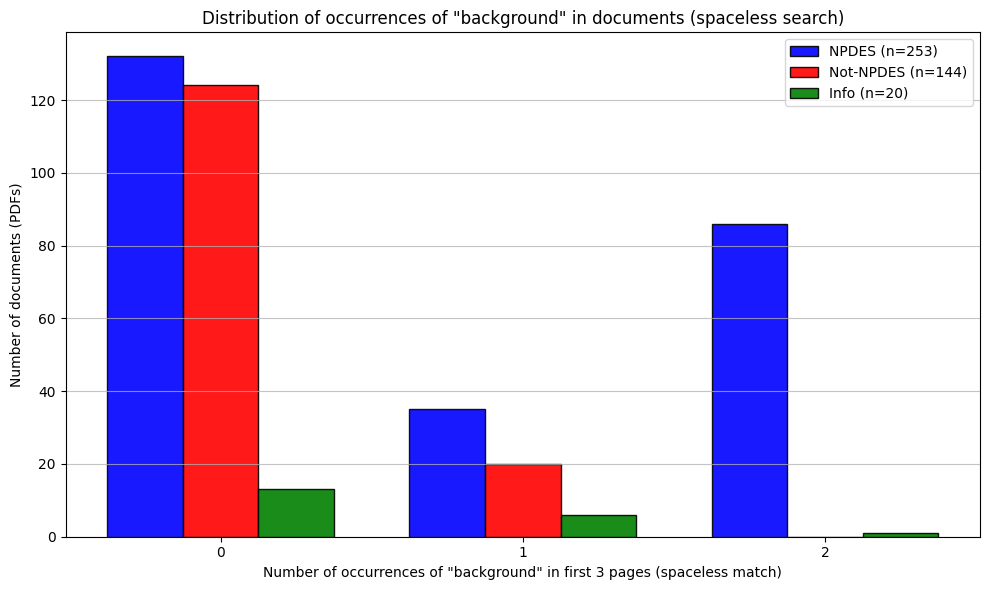

Saved histogram to output/2025-10-8-test1/background_occurrences_histogram_spaceless.png


In [9]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word = 'background'
print(f"Analyzing occurrences of the word: {word}")
npdes_occurrences = search_keywords(path_npdes, word, max_pages)
non_npdes_occurrences = search_keywords(path_non_npdes, word, max_pages)
info_occurrences = search_keywords(path_info, word, max_pages)
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages)

In [14]:
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

NPDES PDF with zero occurrences: R8-2022-0050_WDR_OCWD_GWRS.pdf


Analyzing occurrences of the word: the following permittee is subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941097856)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941091872)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941091872)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096800)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096800)]


0.078125
Analyzing occurrences of the word: the following permittees are subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941090816)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096624)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096624)]


0.00390625
Analyzing occurrences of the word: the following dischargers are subject to waste discharge requirements


...

0.0078125
Analyzing occurrences of the word: the following discharger is subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941085888)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941085888)]


0.44140625
Analyzing occurrences of the word: the following entity is subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088880)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088880)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096272)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096272)]


0.015625
NPDES occurrences: count=256, min=0, max=2, mean=0.55
Not-NPDES occurrences: count=144, min=0, max=0, mean=0.00
Info occurrences: count=17, min=0, max=0, mean=0.00


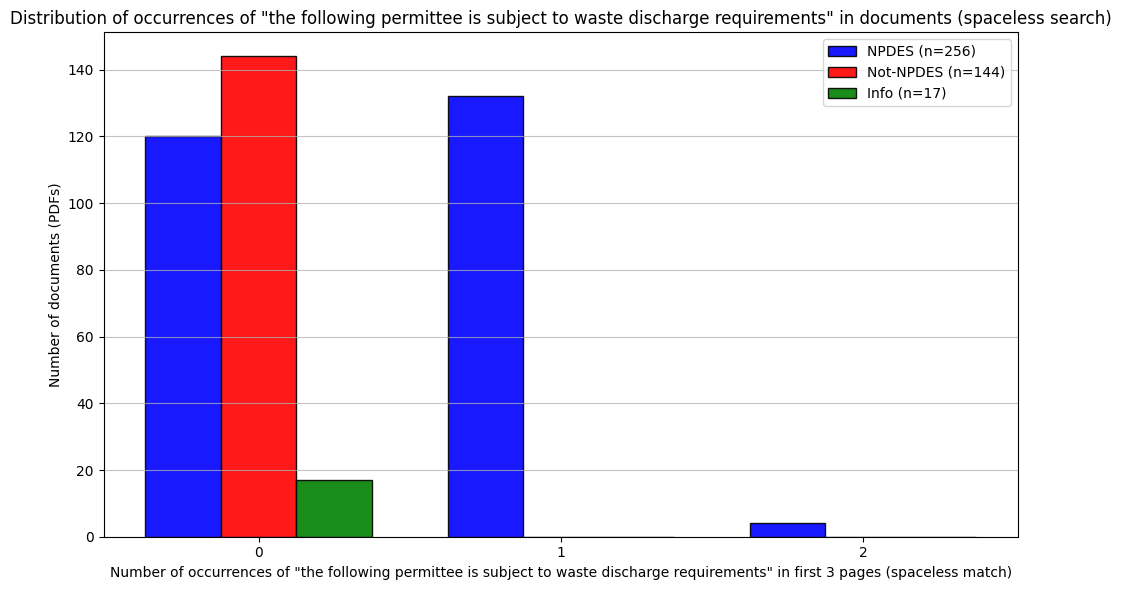

Saved histogram to output/2025-10-8-test1/the_following_permittee_is_subject_to_waste_discharge_requirements_occurrences_histogram_spaceless.png


In [8]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word1 = 'the following permittee is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word1}")
npdes_occurrences1 = search_keywords(path_npdes, word1, max_pages)
non_npdes_occurrences1 = search_keywords(path_non_npdes, word1, max_pages)
info_occurrences1 = search_keywords(path_info, word1, max_pages)
print(sum(npdes_occurrences1)/len(npdes_occurrences1))

word2 = 'the following permittees are subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word2}")
npdes_occurrences2 = search_keywords(path_npdes, word2, max_pages)
non_npdes_occurrences2 = search_keywords(path_non_npdes, word2, max_pages)
info_occurrences2 = search_keywords(path_info, word2, max_pages)
print(sum(npdes_occurrences2)/len(npdes_occurrences2))

word3 = 'the following dischargers are subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word3}")
npdes_occurrences3 = search_keywords(path_npdes, word3, max_pages)
non_npdes_occurrences3 = search_keywords(path_non_npdes, word3, max_pages)
info_occurrences3 = search_keywords(path_info, word3, max_pages)
print(sum(npdes_occurrences3)/len(npdes_occurrences3))

word4 = 'the following discharger is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word4}")
npdes_occurrences4 = search_keywords(path_npdes, word4, max_pages)
non_npdes_occurrences4 = search_keywords(path_non_npdes, word4, max_pages)
info_occurrences4 = search_keywords(path_info, word4, max_pages)
print(sum(npdes_occurrences4)/len(npdes_occurrences4))

word5 = 'the following entity is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word5}")
npdes_occurrences5 = search_keywords(path_npdes, word5, max_pages)
non_npdes_occurrences5 = search_keywords(path_non_npdes, word5, max_pages)
info_occurrences5 = search_keywords(path_info, word5, max_pages)
print(sum(npdes_occurrences5)/len(npdes_occurrences5))

npdes_occurrences = [a + b + c + d + e for a, b, c, d, e in zip(npdes_occurrences1, npdes_occurrences2, npdes_occurrences3, npdes_occurrences4, npdes_occurrences5)]
non_npdes_occurrences = [a + b + c + d + e for a, b, c, d, e in zip(non_npdes_occurrences1, non_npdes_occurrences2, non_npdes_occurrences3, non_npdes_occurrences4, non_npdes_occurrences5)]
info_occurrences = [a + b + c + d + e for a, b, c, d, e in zip(info_occurrences1, info_occurrences2, info_occurrences3, info_occurrences4, info_occurrences5)]
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word1, out_dir, max_pages)

In [11]:
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

NPDES PDF with zero occurrences: 8672_R4-2003-0141_FS.pdf
NPDES PDF with zero occurrences: ARC NPDES - Adopted  CI-10317 111623.pdf
NPDES PDF with zero occurrences: Adopted ECLWRF NPDES CI-7449 111623.pdf
NPDES PDF with zero occurrences: Adopted OWRRF NPDES CI-2022 06172024 signed.pdf
NPDES PDF with zero occurrences: AmendingOrderR920210199_Digitally Signed signed dwg 12-14-21 (1).pdf
NPDES PDF with zero occurrences: AmendingOrderR920210199_Digitally Signed signed dwg 12-14-21.pdf
NPDES PDF with zero occurrences: AmendingOrderR920210204_DigitalSignature signed dwg 12-17-21.pdf
NPDES PDF with zero occurrences: Benicia R2-2025-0001.pdf
NPDES PDF with zero occurrences: Burlingame R2-2023-0010.pdf
NPDES PDF with zero occurrences: CA0037737 NSMCSD Order R2-2022-0036.pdf
NPDES PDF with zero occurrences: CA0037834 Palo Alto Order R2-2025-0003.pdf
NPDES PDF with zero occurrences: City of Livermore - R2-2022-2025.pdf
NPDES PDF with zero occurrences: DSRSD - R2-2022-2024.pdf
NPDES PDF with zero 

IndexError: list index out of range

Analyzing occurrences of the word: set forth in this order


unknown widths : 
[0, IndirectObject(14094, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941097152)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089936)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089936)]


NPDES occurrences: count=255, min=0, max=3, mean=0.98
Not-NPDES occurrences: count=144, min=0, max=1, mean=0.10
Info occurrences: count=18, min=0, max=2, mean=0.11


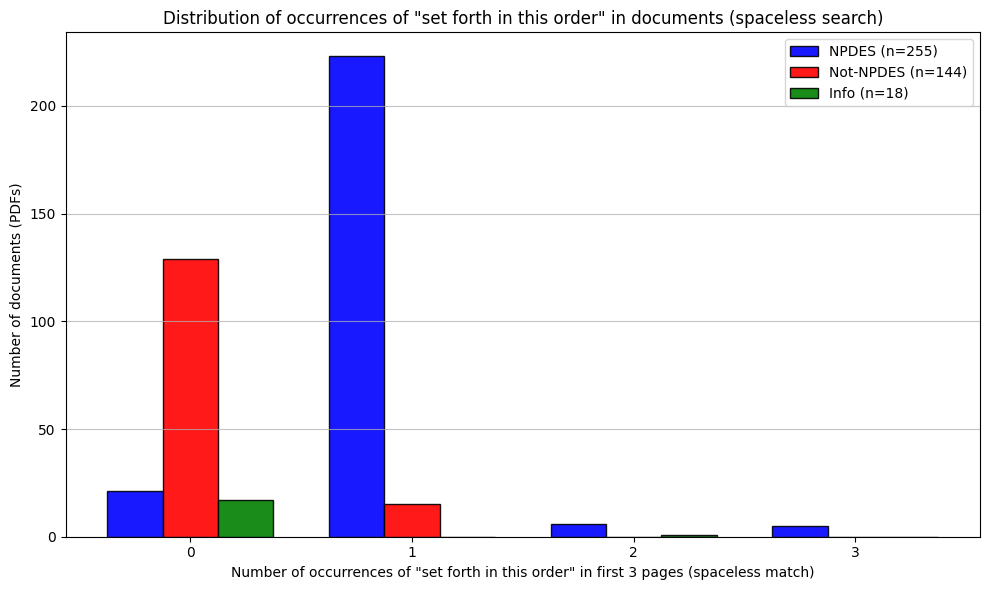

Saved histogram to output/2025-10-8-test1/set_forth_in_this_order_occurrences_histogram_spaceless.png


In [12]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word = 'set forth in this order'
print(f"Analyzing occurrences of the word: {word}")
npdes_occurrences = search_keywords(path_npdes, word, max_pages)
non_npdes_occurrences = search_keywords(path_non_npdes, word, max_pages)
info_occurrences = search_keywords(path_info, word, max_pages)
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages)

In [13]:
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

NPDES PDF with zero occurrences: 8672_R4-2003-0141_FS.pdf
NPDES PDF with zero occurrences: Order R7-2023-0046- Date Gardens MHPWWTP_NPDES.pdf
NPDES PDF with zero occurrences: R5-2017-0085-01.pdf
NPDES PDF with zero occurrences: R5-2019-0052.pdf
NPDES PDF with zero occurrences: R7-2020-0010.pdf
NPDES PDF with zero occurrences: R7-2021-0002.pdf
NPDES PDF with zero occurrences: R7-2021-0005.pdf
NPDES PDF with zero occurrences: R7-2021-0045.pdf
NPDES PDF with zero occurrences: R7-2022-0005.pdf
NPDES PDF with zero occurrences: R7-2022-0007.pdf
NPDES PDF with zero occurrences: R7-2023-0002.pdf
NPDES PDF with zero occurrences: R7-2023-0003.pdf
NPDES PDF with zero occurrences: R7-2023-0013.pdf
NPDES PDF with zero occurrences: R7-2023-0041.pdf
NPDES PDF with zero occurrences: R7-2024-0019.pdf
NPDES PDF with zero occurrences: R7-2024-0041.pdf
NPDES PDF with zero occurrences: R7-2025-0007.pdf
NPDES PDF with zero occurrences: R8-2021-0010_OCSD (1).pdf
NPDES PDF with zero occurrences: R8-2021-0010_

Analyzing occurrences of the word: table 1. discharger information


unknown widths : 
[0, IndirectObject(14094, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149212768)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149214000)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149214000)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149216640)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149216640)]


Analyzing occurrences of the word: set forth in this order


unknown widths : 
[0, IndirectObject(14094, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149222624)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149221568)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149221568)]


NPDES occurrences: count=258, min=1, max=5, mean=2.05
Not-NPDES occurrences: count=141, min=0, max=1, mean=0.09
Info occurrences: count=18, min=0, max=0, mean=0.00


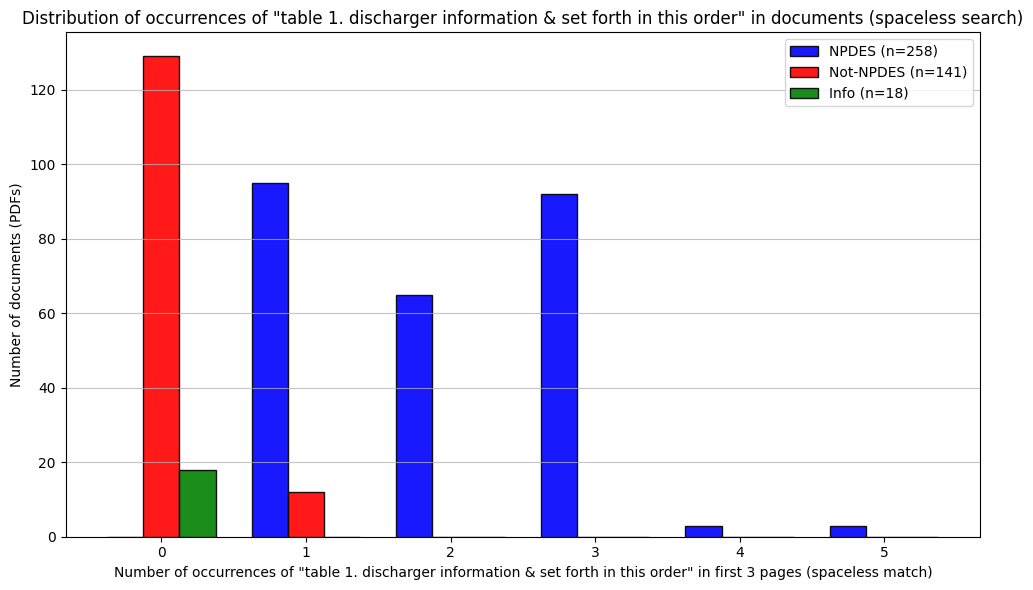

Saved histogram to output/2025-10-8-test1/table_1._discharger_information_&_set_forth_in_this_order_occurrences_histogram_spaceless.png
Analyzing occurrences of the word: table 1. discharger information


In [10]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word1 = 'table 1. discharger information'
print(f"Analyzing occurrences of the word: {word1}")
npdes_occurrences1 = search_keywords(path_npdes, word1, max_pages)
non_npdes_occurrences1 = search_keywords(path_non_npdes, word1, max_pages)
info_occurrences1 = search_keywords(path_info, word1, max_pages)


word2 = 'set forth in this order'
print(f"Analyzing occurrences of the word: {word2}")
npdes_occurrences2 = search_keywords(path_npdes, word2, max_pages)
non_npdes_occurrences2 = search_keywords(path_non_npdes, word2, max_pages)
info_occurrences2 = search_keywords(path_info, word2, max_pages)

npdes_occurrences = [a + b for a, b in zip(npdes_occurrences1, npdes_occurrences2)]
non_npdes_occurrences = [a + b for a, b in zip(non_npdes_occurrences1, non_npdes_occurrences2)]
info_occurrences = [a + b for a, b in zip(info_occurrences1, info_occurrences2)]
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word1 + " & " + word2, out_dir, max_pages)
print(f"Analyzing occurrences of the word: {word1}")
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

In [13]:
for i, nb in enumerate (info_occurrences):
    if nb >0:
        pdf_file_name = sorted(os.listdir(path_info))[i]
        print(f"Info PDF with more than 0 occurrences: {pdf_file_name}")

Info PDF with more than 0 occurrences: 12-0050_City_of_Colton_WDR.pdf
Info PDF with more than 0 occurrences: r9-2023_0131.pdf


In [9]:
# plot the first page read through pypfd of a pdf file
def plot_first_page_pdf(file_path):
    try:
        with open(file_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            if len(reader.pages) > 0:
                page = reader.pages[0]
                text = page.extract_text()
                if text:
                    print(text[:3000])  # print first 3000 chars
                else:
                    print(f"No text extracted from the first page of {file_path}")
            else:
                print(f"No pages found in {file_path}")
    except Exception as e:
        print(f"Error reading or plotting first page of {file_path}: {e}")

plot_first_page_pdf('output/2025-10-8-test1/NPDES/10512_R4-2020-0053_WDR_PKG.pdf')

  ADOPTED ORDER (04/16/20)  CALIFORNIA REGIONAL WATER QUALITY CONTROL BOARD  
LOS ANGELES  REGION  
320 West 4th Street, Suite 200, Los Angeles, California 90013  
(213) 576 -6600   Fax (213) 576 -6660  
http://www.waterboards.ca.gov/losa ngeles/   
ORDER R4-2020-0053  
NPDES NO. CA0064670  
WASTE DISCHARGE REQUIREMENTS  
 FOR THE  LOS ANGELES COUNTY DEPARTMENT OF BEACHES AND HARBORS , 
ROYAL PALMS PUBLIC RESTROOM  
DISCHARGE TO THE PACIFIC OCEAN VIA THE JOINT WATER POLLUTION 
CONTROL PLANT   
The followi ng Discharger is subject to waste discharge requirements (WDR s) set forth in this 
Order:  
Table 1. Discharger Information  
Disc harger  Los Angeles County Department of Beaches and Harbors (Discharger  
or Permittee ) 
Name of F acility  Royal Palms Public Restroom  
Facility Address  2100 Paseo del Mar  
San Pedro, CA 90732  
Los Angeles County  
Table 2. Discharge Location  
Discharge 
Point  Effluent Description  Discharge 
Point 
Latitude  Discharge Point 
Longitu de Receivin

In [5]:
def find_best_words(folder_path, max_pages, max_words=20):
    """
    Analyze text in PDFs within `folder_path` to identify the most frequent words
    (excluding common stop words) in the first `max_pages` pages of each PDF.

    Args:
        folder_path (str): Path to the folder containing PDF files.
        max_pages (int): Maximum number of pages to analyze per PDF.
        max_words (int): Number of top frequent words to return.
    Returns:
        List of tuples (word, count) for the most frequent words.
    """
    from collections import Counter
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

    all_text = []
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return []

    filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')])
    for filename in filenames:
        file_path = os.path.join(folder_path, filename)

        # collect page text
        page_texts = []
        try:
            with open(file_path, 'rb') as f:
                try:
                    reader = PyPDF2.PdfReader(f)
                except Exception as e_open:
                    # Try pdfminer fallback if PyPDF2 cannot open
                    try:
                        from pdfminer.high_level import extract_text
                        text = extract_text(file_path, maxpages=max_pages)
                        if text:
                            page_texts = [text]
                    except Exception:
                        page_texts = []
                else:
                    num_pages = min(len(reader.pages), max_pages)
                    for page_num in range(num_pages):
                        try:
                            page = reader.pages[page_num]
                            text = page.extract_text() or ''
                        except Exception:
                            text = ''
                        if text:
                            page_texts.append(text)
        except Exception:
            page_texts = []

        combined = ' '.join(page_texts)
        normalized = normalize_text(combined)
        all_text.append(normalized)

    combined_all = ' '.join(all_text)
    words = re.findall(r'\b\w+\b', combined_all)
    words_filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]

    counter = Counter(words_filtered)
    most_common = counter.most_common(max_words)

    return most_common

def find_best_n_more_wording(folder_path, max_pages, max_sentences=10, n_words=3):
    """
    Analyze text in PDFs within `folder_path` to identify the most frequent of more than `n_words` words
    (excluding common stop words) in the first `max_pages` pages of each PDF.

    Args:
        folder_path (str): Path to the folder containing PDF files.
        max_pages (int): Maximum number of pages to analyze per PDF.
        max_sentences (int): Number of top frequent sentences to return.
    Returns:
        List of tuples (more than n_words word sequence, count) for the most frequent sequences.
    """

    from collections import Counter
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    all_text = []
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return []
    filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')])
    for filename in filenames:
        file_path = os.path.join(folder_path, filename)

        # collect page text
        page_texts = []
        try:
            with open(file_path, 'rb') as f:
                try:
                    reader = PyPDF2.PdfReader(f)
                except Exception as e_open:
                    # Try pdfminer fallback if PyPDF2 cannot open
                    try:
                        from pdfminer.high_level import extract_text
                        text = extract_text(file_path, maxpages=max_pages)
                        if text:
                            page_texts = [text]
                    except Exception:
                        page_texts = []
                else:
                    num_pages = min(len(reader.pages), max_pages)
                    for page_num in range(num_pages):
                        try:
                            page = reader.pages[page_num]
                            text = page.extract_text() or ''
                        except Exception:
                            text = ''
                        if text:
                            page_texts.append(text)
        except Exception:
            page_texts = []

        combined = ' '.join(page_texts)
        normalized = normalize_text(combined)
        all_text.append(normalized)
    combined_all = ' '.join(all_text)
    sentences = re.split(r'(?<=[.!?]) +', combined_all)

# Example usage
path_npdes = 'output/2025-10-8-test1/NPDES'
max_pages=3
best_words = find_best_words(path_npdes, max_pages, max_words=20)
print("Most frequent words in NPDES PDFs:")
for word, count in best_words:
    print(f"{word}: {count}")

best_sentences = find_best_sentence(path_npdes, max_pages, max_sentences=10)
print("\nMost frequent sentences in NPDES PDFs:")
for sentence, count in best_sentences:
    print(f"{sentence}: {count}")


unknown widths : 
[0, IndirectObject(14094, 0, 133505149217344)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149217344)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149217344)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149217344)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149217344)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505149217520)]


Most frequent words in NPDES PDFs:
discharge: 4292
water: 3834
order: 3677
requirements: 2062
table: 1935
effluent: 1706
limitations: 1683
attachment: 1626
facility: 1594
provisions: 1479
board: 1391
information: 1358
san: 1286
california: 1258
waste: 1227
npdes: 1168
discharger: 1099
regional: 1088
point: 1076
shall: 908


unknown widths : 
[0, IndirectObject(14094, 0, 133511161316992)]
unknown widths : 
[0, IndirectObject(14089, 0, 133511161316992)]
unknown widths : 
[0, IndirectObject(14084, 0, 133511161316992)]
unknown widths : 
[0, IndirectObject(14079, 0, 133511161316992)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505280630944)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505271237808)]



Most frequent sentences in NPDES PDFs:
receiving water limitations ................................: 130
land discharge specifications – not applicable ................................: 86
environmental protection agency (u.s.: 75
groundwater limitations – not applicable ................................: 65
background and rationale for requirements.: 65
e-1 attachment f – fact sheet ................................: 63
recycling specifications – not applicable ................................: 63
surface water limitations ................................: 62
c-1 attachment d – standard provisions ................................: 60
notification of interested parties.: 55


In [6]:
def find_most_common_ngrams(folder_path, n=3, max_pages=3, top_k=20, min_word_length=7):
    """Find the most frequent n-word sequences (n-grams) across all PDFs in
    folder_path, looking only at the first `max_pages` pages of each PDF.

    Args:
        folder_path (str): directory with PDF files.
        n (int): size of the n-gram (e.g., 3 for trigrams).
        max_pages (int): number of pages to read per PDF.
        top_k (int): number of top n-grams to return.
        min_word_length (int): minimum length of word tokens to consider.

    Returns:
        List of (ngram, count) pairs sorted by count desc, length top_k.
    """
    from collections import Counter, defaultdict
    try:
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    except Exception:
        ENGLISH_STOP_WORDS = set()

    def tokenize(text):
        # basic word tokenizer: keep only letters and digits, split on non-word
        tokens = re.findall(r"\b[\w']+\b", text.lower())
        tokens = [t for t in tokens if len(t) >= min_word_length]
        return tokens

    # helper to extract normalized text (first max_pages pages) from a single PDF
    def extract_pdf_text(file_path, max_pages):
        page_texts = []
        try:
            with open(file_path, 'rb') as f:
                try:
                    reader = PyPDF2.PdfReader(f)
                except Exception:
                    # fallback pdfminer
                    try:
                        from pdfminer.high_level import extract_text
                        txt = extract_text(file_path, maxpages=max_pages)
                        return normalize_text(txt) if txt else ''
                    except Exception:
                        return ''
                num_pages = min(len(reader.pages), max_pages)
                for i in range(num_pages):
                    try:
                        page = reader.pages[i]
                        text = page.extract_text() or ''
                    except Exception:
                        text = ''
                    if text:
                        page_texts.append(text)
        except Exception:
            return ''
        return normalize_text(' '.join(page_texts))

    filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')])
    ngram_counter = Counter()
    ngram_files = defaultdict(list)  # map ngram -> list of filenames where it occurs

    for fname in filenames:
        path = os.path.join(folder_path, fname)
        txt = extract_pdf_text(path, max_pages)
        if not txt:
            continue
        tokens = [t for t in tokenize(txt) if t not in ENGLISH_STOP_WORDS]
        if len(tokens) < n:
            continue
        for i in range(len(tokens) - n + 1):
            ngram = ' '.join(tokens[i:i+n])
            # skip ngrams that are mostly stopwords or very short tokens
            if all(w in ENGLISH_STOP_WORDS for w in ngram.split()):
                continue
            ngram_counter[ngram] += 1
            if fname not in ngram_files[ngram]:
                ngram_files[ngram].append(fname)

    most_common = ngram_counter.most_common(top_k)
    # attach file examples for each ngram
    result = [(ng, cnt, ngram_files.get(ng, [])[:5]) for ng, cnt in most_common]
    return result


# Demo: find top trigrams in NPDES folder (first 3 pages)
if os.path.exists(path_npdes):
    print('Scanning for top trigrams in NPDES PDFs...')
    top_trigrams = find_most_common_ngrams(path_npdes, n=3, max_pages=3, top_k=20)
    for ng, cnt, files in top_trigrams:
        print(f"{ng}: {cnt} (examples: {files})")
else:
    print(f"Folder not found: {path_npdes}")


Scanning for top trigrams in NPDES PDFs...


unknown widths : 
[0, IndirectObject(14094, 0, 133505271245376)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505271245376)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505271245376)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505271245376)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505239271392)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505271245728)]


regional quality control: 695 (examples: ['0755_R4-2021-0097_WDR_PKG.pdf', '10512_R4-2020-0053_WDR_PKG.pdf', '12-0050_City_of_Colton_WDR.pdf', '12_0101_NPDES_Occidental.pdf', '15_0002_Tulelake_WDR_revised_030415.pdf'])
california regional quality: 635 (examples: ['0755_R4-2021-0097_WDR_PKG.pdf', '10512_R4-2020-0053_WDR_PKG.pdf', '12-0050_City_of_Colton_WDR.pdf', '12_0101_NPDES_Occidental.pdf', '15_0002_Tulelake_WDR_revised_030415.pdf'])
effluent limitations discharge: 438 (examples: ['0755_R4-2021-0097_WDR_PKG.pdf', '15_0002_Tulelake_WDR_revised_030415.pdf', '18_0001_Graton_NPDES.pdf', '18_0046_Ferndale_NPDES.pdf', '20220829_Order R3-2022-0010_Final (ACC).pdf'])
monitoring reporting program: 368 (examples: ['0755_R4-2021-0097_WDR_PKG.pdf', '10512_R4-2020-0053_WDR_PKG.pdf', '12_0101_NPDES_Occidental.pdf', '15_0002_Tulelake_WDR_revised_030415.pdf', '18_0001_Graton_NPDES.pdf'])
prohibitions effluent limitations: 294 (examples: ['0755_R4-2021-0097_WDR_PKG.pdf', '10512_R4-2020-0053_WDR_PKG.

unknown widths : 
[0, IndirectObject(14094, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505120091520)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505120091520)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505120079904)]
unknown widths : 
[0, IndirectObject(15704, 0, 133505120079904)]
unknown widths : 
[0, IndirectObject(14094, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14089, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14084, 0, 133505149221392)]
unknown widths : 
[0, IndirectObject(14079, 0, 133505149221392)]
unknown widths : 
[0, Ind

NPDES occurrences: count=0, min=0, max=0, mean=0.00
Not-NPDES occurrences: count=0, min=0, max=0, mean=0.00
Info occurrences: count=0, min=0, max=0, mean=0.00


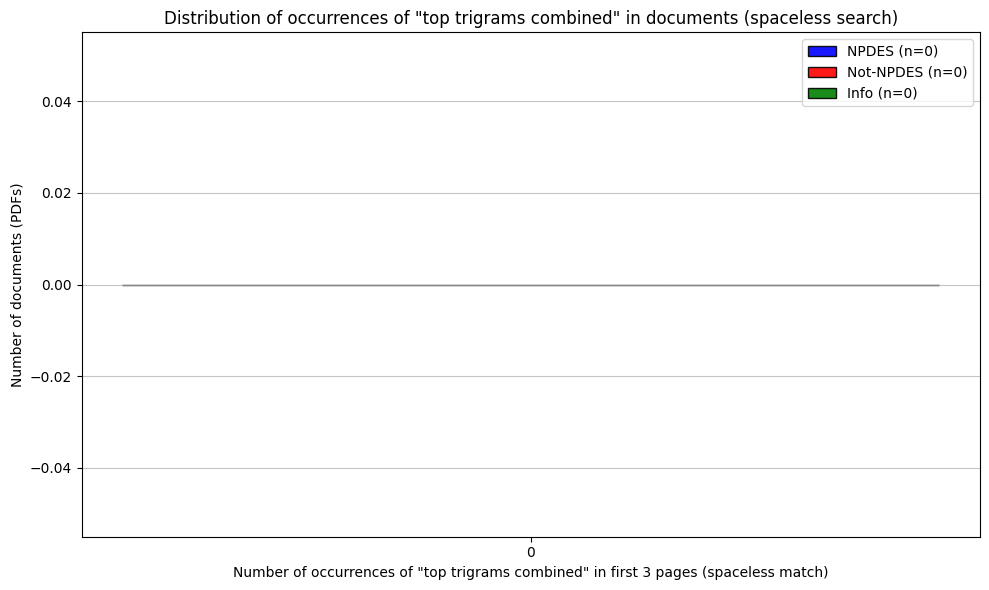

Saved histogram to output/2025-10-8-test1/top_trigrams_combined_occurrences_histogram_spaceless.png


In [9]:
# show the number of occurrences of these trigrams in NPDES, Not-NPDES, and Info folders
from numpy import empty
max_pages=3

npdes_occurrences_tot = []
non_npdes_occurrences_tot = []
info_occurrences_tot = []
for ng, _, _ in top_trigrams:
    npdes_occurrences = search_keywords(path_npdes, ng, max_pages)
    non_npdes_occurrences = search_keywords(path_non_npdes, ng, max_pages)
    info_occurrences = search_keywords(path_info, ng, max_pages)
    if npdes_occurrences_tot is empty:
        npdes_occurrences_tot = npdes_occurrences
        non_npdes_occurrences_tot = non_npdes_occurrences
        info_occurrences_tot = info_occurrences
    else:
        npdes_occurrences_tot = [a + b for a, b in zip(npdes_occurrences_tot, npdes_occurrences)]
        non_npdes_occurrences_tot = [a + b for a, b in zip(non_npdes_occurrences_tot, non_npdes_occurrences)]
        info_occurrences_tot = [a + b for a, b in zip(info_occurrences_tot, info_occurrences)] 
analyze_and_plot(npdes_occurrences_tot, non_npdes_occurrences_tot, info_occurrences_tot, "top trigrams combined", out_dir, max_pages) 

